# Clustering jerárquico con huecos: sueño, salud y estilo de vida

Completa las celdas siguientes para aplicar:

- clustering jerárquico
- dendrograma
- análisis de clústeres
- comparación con K-Means
- Utiliza para la resolución https://scikit-learn.org/stable/ y https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

>El origen del Dataset es https://www.kaggle.com/

## Contexto del dataset

El dataset recoge hábitos de sueño, salud y estilo de vida de aproximadamente 400 personas. Cada fila representa un individuo. Las variables que usaremos son:

| Variable | Tipo | Rango / Valores | Qué mide |
|---|---|---|---|
| Age | Numérica | 27 – 59 | Edad en años |
| Sleep Duration | Numérica | 5.8 – 8.5 | Horas de sueño por noche |
| Quality of Sleep | Numérica | 1 – 10 | Calidad subjetiva del sueño |
| Physical Activity Level | Numérica | 30 – 90 | Minutos de actividad física diaria |
| Stress Level | Numérica | 1 – 10 | Nivel de estrés autopercibido |
| Heart Rate | Numérica | 65 – 86 | Pulsaciones en reposo (bpm) |
| Daily Steps | Numérica | 3.000 – 10.000 | Pasos diarios |

También existen variables categóricas como `Gender` y `Sleep Disorder` que no entran en el clustering pero pueden usarse para interpretar los grupos.

---

**Antes de ejecutar nada, analiza:**  
¿Qué variable crees que tendrá más peso a la hora de separar los grupos?  
¿Esperas que el género influya en los clústeres resultantes?

Anota tu hipótesis aquí y compárala con los resultados al final.

> *Mi hipótesis:*

## 1. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram , linkage, fcluster

## 2. Carga del dataset

In [3]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2b. Comprobación y tratamiento de valores nulos

Antes de continuar, verifica si el dataset tiene valores que deban tener un tratamiento específico.  
Esta decisión afecta a todo el análisis posterior.

In [4]:
# Nulos por columna
print(df.isna().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [5]:
# ¿Qué porcentaje representa cada uno?
print((df.isna() / len(df) * 100).round(2))

     Person ID  Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0          0.0     0.0  0.0         0.0             0.0               0.0   
1          0.0     0.0  0.0         0.0             0.0               0.0   
2          0.0     0.0  0.0         0.0             0.0               0.0   
3          0.0     0.0  0.0         0.0             0.0               0.0   
4          0.0     0.0  0.0         0.0             0.0               0.0   
..         ...     ...  ...         ...             ...               ...   
369        0.0     0.0  0.0         0.0             0.0               0.0   
370        0.0     0.0  0.0         0.0             0.0               0.0   
371        0.0     0.0  0.0         0.0             0.0               0.0   
372        0.0     0.0  0.0         0.0             0.0               0.0   
373        0.0     0.0  0.0         0.0             0.0               0.0   

     Physical Activity Level  Stress Level  BMI Category  Blood Pressure  \

In [6]:
# Decide una estrategia y completa:
# Opción A — eliminar filas con nulos
# Opción B — imputar con la media
# Opción C — imputar con la mediana

df.dropna(inplace=True)   # Opción A
# df[columnas] = df[columnas].fillna(df[columnas].______)  # Opción B o C

# Comprobación final: debe dar 0 en todas las columnas
print("Nulos restantes:", df.isnull().sum())

Nulos restantes: Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


## 3. Exploración inicial

In [7]:
print("Filas y columnas:", df.shape)
print(df.columns.tolist())

Filas y columnas: (155, 13)
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


## 4. Selección de variables

Usa estas variables numéricas:
- Age
- Sleep Duration
- Quality of Sleep
- Physical Activity Level
- Stress Level
- Heart Rate
- Daily Steps

In [8]:
columnas = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

X = df[columnas]
X.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
3,28,5.9,4,30,8,85,3000
4,28,5.9,4,30,8,85,3000
5,28,5.9,4,30,8,85,3000
6,29,6.3,6,40,7,82,3500
16,29,6.5,5,40,7,80,4000


## 5. Escalado

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Matriz de enlace

In [10]:
Z = linkage(X_scaled, method="ward")
Z[:5]

array([[  0.,   1.,   0.,   2.],
       [  2., 155.,   0.,   3.],
       [ 11.,  12.,   0.,   2.],
       [  4.,   6.,   0.,   2.],
       [  7.,   8.,   0.,   2.]])

## 7. Dendrograma

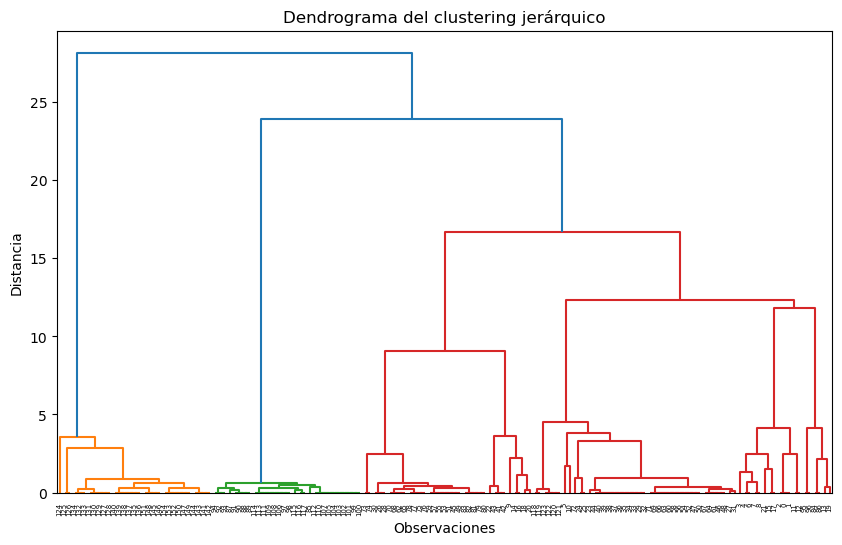

In [11]:
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrograma del clustering jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

## 8. Número de clústeres

A partir del dendrograma, crea 3 clústeres.

In [12]:
clusters_h = fcluster(Z, t=3, criterion="maxclust")
df["cluster_jerarquico"] = clusters_h

## 9. Tamaño de cada clúster

In [13]:
df["cluster_jerarquico"].value_counts()

cluster_jerarquico
3    94
1    31
2    30
Name: count, dtype: int64

## 10. Perfil medio de cada clúster

In [ ]:
perfil_h = df.groupby("cluster_jerarquico")[df.select_dtypes(include="number").columns].mean().round(2)
perfil_h

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,cluster_jerarquico
cluster_jerarquico,,,,,,,,,
1,356.87,57.84,8.10,9.00,73.55,3.06,68.16,6806.45,1.0
2,285.67,49.77,6.06,6.00,90.00,8.00,75.00,10000.00,2.0
3,194.73,41.94,6.63,6.45,47.44,5.95,71.96,5720.21,3.0


## 11. Relación con género

In [15]:
pd.crosstab(df["Gender"], df["cluster_jerarquico"], normalize="index").round(3)

cluster_jerarquico,1,2,3
Gender,,,
Female,0.301,0.291,0.408
Male,0.000,0.000,1.000


## 12. K-Means

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_k = kmeans.fit_predict(X_scaled)

df["cluster_kmeans"] = clusters_k

## 13. Perfil medio en K-Means

In [18]:
perfil_k = df.groupby("cluster_kmeans")[df.select_dtypes(include="number").columns].mean().round(2)
perfil_k

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,cluster_jerarquico,cluster_kmeans
cluster_kmeans,,,,,,,,,,
0,335.35,55.70,8.06,8.89,75.95,3.27,69.32,6767.57,1.32,0.0
1,192.73,41.75,6.54,6.32,44.65,6.06,71.73,5662.50,3.00,1.0
2,285.67,49.77,6.06,6.00,90.00,8.00,75.00,10000.00,2.00,2.0


## 14. Comparación entre métodos: Matriz de Confusión

> **Nota importante:** los números de clúster asignados por cada algoritmo son arbitrarios. El clúster "1" del jerárquico puede contener los mismos individuos que el clúster "2" de K-Means aunque sean el mismo grupo en la práctica. Interpreta la matriz fijándote en la **concentración de valores**, no en que coincidan los números.

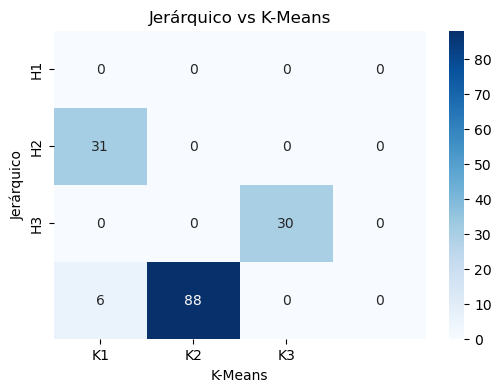

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Construye la matriz cruzando ambos métodos
matriz = confusion_matrix(df["cluster_jerarquico"], df["cluster_kmeans"])

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["K1", "K2", "K3"],
    yticklabels=["H1", "H2", "H3"]
)
plt.xlabel("K-Means")
plt.ylabel("Jerárquico")
plt.title("Jerárquico vs K-Means")
plt.show()

**Reflexiona:** ¿Qué significa que haya valores altos fuera de la diagonal?  
¿Coinciden bien los dos métodos o hay grupos que se mezclan?

> *Mi respuesta:* Los dos métodos coinciden bastante bien en general. Los valores altos se concentran en tres celdas que forman una especie de diagonal desplazada (H2→K1=31, H3→K2=30, H4→K2=88), lo que indica que cada clúster jerárquico se corresponde claramente con uno de K-Means, aunque con etiquetas distintas. La pequeña discrepancia de 6 individuos en H4→K1 es poco relevante. Sin embargo, el clúster H1 tiene todos ceros.

## 15. Visualización

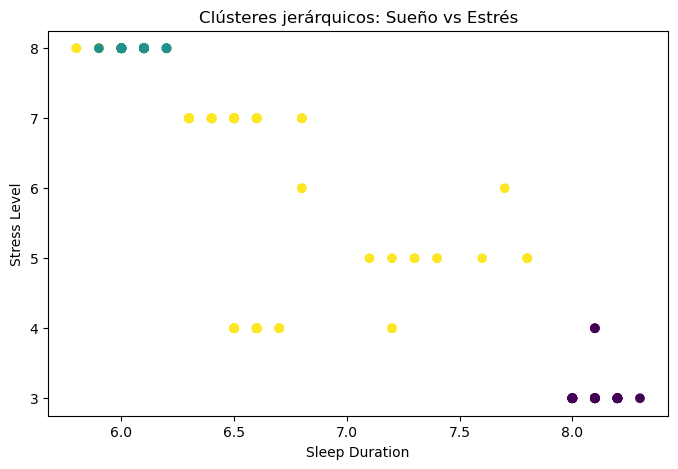

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sleep Duration"], df["Stress Level"], c=df["cluster_jerarquico"])
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.title("Clústeres jerárquicos: Sueño vs Estrés")
plt.show()

## 16. Cuestiones finales

Responde:

1. ¿Cuántos clústeres observas en el dendrograma?
    -   En el dendrograma se observan 3 clusters.

2. ¿Cómo describirías cada grupo?
    -   Clúster 1 (mayor, saludable y descansado): personas de mayor edad (57 años de media), con mucho sueño (8.1h), 
        excelente calidad de sueño (9/10) y estrés muy bajo (3.06).Son los que mejor duermen.

    -   Clúster 2 (activo pero estresado): perfil de mediana edad (49 años), actividad física máxima (90 min/día), 
        10.000 pasos diarios, pero con estrés muy alto (8/10) y la peor calidad de sueño (6/10).

    -   Clúster 3 (joven e intermedio): los más jóvenes (41 años), actividad física moderada (47 min/día), 
        estrés medio (5.95) y calidad de sueño media (6.45).

3. ¿Qué variables distinguen mejor unos grupos de otros?
    -   Stress Level y Quality of Sleep son las que más separan los grupos, seguidas de Sleep Duration y Physical 
        Activity Level. Es llamativo que el clúster 2 tenga la mayor actividad física pero el peor sueño, lo que 
        sugiere que el estrés tiene más peso que el ejercicio.

4. ¿Coinciden mucho los grupos jerárquicos y los de K-Means?

5. ¿Crees que las personas se agrupan más por género o por hábitos?

6. ¿Se cumplió tu hipótesis inicial sobre qué variable tendría más peso?
